# Netflix Movie Duration Analysis

**Hamed Dhiaa · Python / pandas / Matplotlib**

A learning project based on DataCamp's Netflix investigation exercise. The supplied dataset is a historical catalogue snapshot, not the current Netflix catalogue.

**Question:** Does the distribution of movie runtimes by release year provide convincing evidence that movies are getting shorter?

Run all cells from top to bottom. In Google Colab, upload `netflix_data.csv` to the session first. Locally, keep the CSV in the notebook directory.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

data_path = Path("netflix_data.csv")
if not data_path.is_file():
    raise FileNotFoundError("Place netflix_data.csv beside the notebook, or upload it to the Colab session.")
netflix_df = pd.read_csv(data_path)
required = {"show_id", "type", "title", "country", "genre", "release_year", "duration"}
missing = required.difference(netflix_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")
netflix_movies = netflix_df.loc[netflix_df["type"].eq("Movie"),
    ["title", "country", "genre", "release_year", "duration"]].copy()
if netflix_movies.empty:
    raise ValueError("The dataset contains no movies.")
for column in ["release_year", "duration"]:
    netflix_movies[column] = pd.to_numeric(netflix_movies[column], errors="raise")
if netflix_movies[["release_year", "duration", "genre"]].isna().any().any():
    raise ValueError("Movie year, duration and genre must be present before plotting.")
if netflix_movies["duration"].le(0).any():
    raise ValueError("Movie durations must be positive.")
short_movies = netflix_movies.loc[netflix_movies["duration"].lt(60)]
summary = pd.Series({
    "Catalogue entries": len(netflix_df),
    "Movies": len(netflix_movies),
    "Movies under 60 minutes": len(short_movies),
    "Missing movie countries": int(netflix_movies["country"].isna().sum()),
    "Duplicate show IDs": int(netflix_df["show_id"].duplicated().sum()),
}, name="Count")
display(summary.to_frame())
display(short_movies.head(10))

,Count
Catalogue entries,7787
Movies,5377
Movies under 60 minutes,420
Missing movie countries,230
Duplicate show IDs,0


,title,country,genre,release_year,duration
35,#Rucker50,United States,Documentaries,2016,56
55,100 Things to do Before High School,United States,Uncategorized,2014,44
67,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,Uncategorized,2017,37
101,3 Seconds Divorce,Canada,Documentaries,2018,53
146,A 3 Minute Hug,Mexico,Documentaries,2019,28
162,A Christmas Special: Miraculous: Tales of Lady...,France,Uncategorized,2016,22
171,A Family Reunion Christmas,United States,Uncategorized,2019,29
177,A Go! Go! Cory Carson Christmas,United States,Children,2020,22
178,A Go! Go! Cory Carson Halloween,NaN,Children,2020,22
179,A Go! Go! Cory Carson Summer Camp,NaN,Children,2020,21


## Movie duration by release year

Each point represents one movie. Colours highlight the original exercise's Children, Documentaries and Stand-Up categories. Other genres are grouped together. `release_year` is the title's release year, not the year it was added to Netflix. Missing country values are retained because country is not used in this chart.

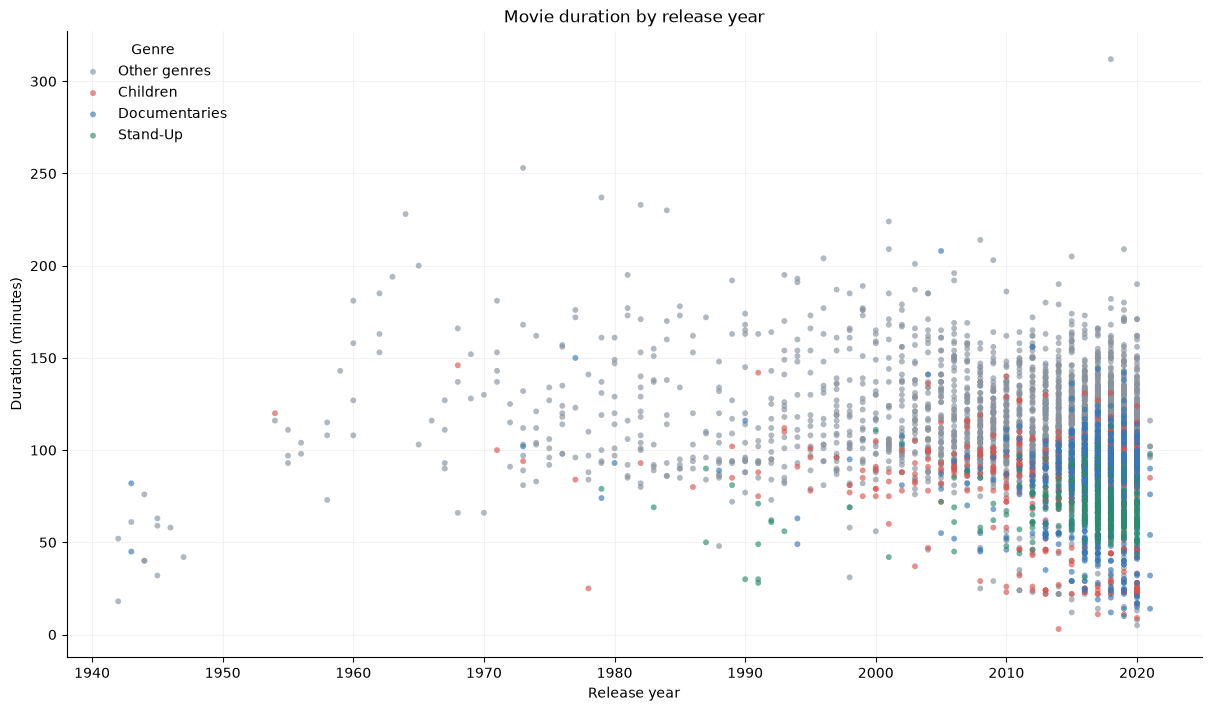

In [2]:
palette = {"Other genres": "#89939e", "Children": "#d9534f",
           "Documentaries": "#3578b8", "Stand-Up": "#2a8c70"}
groups = netflix_movies["genre"].where(
    netflix_movies["genre"].isin(["Children", "Documentaries", "Stand-Up"]), "Other genres")
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
for label, color in palette.items():
    subset = netflix_movies.loc[groups.eq(label)]
    ax.scatter(subset["release_year"], subset["duration"],
               color=color, label=label, s=18, alpha=0.65, edgecolors="none")
ax.set(title="Movie duration by release year", xlabel="Release year", ylabel="Duration (minutes)")
ax.legend(title="Genre", frameon=False)
ax.grid(alpha=0.15)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig("movie_duration.png", dpi=160, facecolor="white")
plt.show()

## Conclusion

**This scatter plot alone is not enough to conclude that movies are getting shorter.** It shows a wide range of runtimes and helps distinguish shorter titles by genre. It does not control for genre composition, unequal numbers of titles per year, or selection into the Netflix catalogue.

The supplied dataset contains 5,377 movies, including 420 under 60 minutes. There are 230 missing movie-country values; these do not affect the year-versus-duration plot. These counts describe this file only.

A stronger follow-up would compare yearly medians and sample sizes, examine trends within genres, and quantify uncertainty. No causal or statistically significant trend is claimed here.

## Attribution

Developed from a DataCamp learning exercise. The original supplied CSV and illustration retain their respective owners' rights. Notebook presentation, data checks and documentation were subsequently refined for this portfolio repository.